# Target-OAR Diagram Layout Template
This notebook is intended to develop and document the Target-OAR diagram layout 
template.  

## Introduction

The Target-OAR diagram layout template is intended to illustrate which OARs 
directly compete with Target structures.  
It will optionally also show opt-OAR structures generated to account for regions 
of overlap between Target and OAR structures.
Once the metrics module is further developed, the template will also display 
the percentage of overlap between the targets and OARs.

The template development process contains the following parts:
1. Create a "Principle Targets" selection filter
2. Select related OARs for each principle target
3. Sort the related OARs based on their relationship to each of the principle targets
5. Add opt-OARs to the diagram layout based on the sorted OARs and principle targets
4. Build a Bipartite format diagram layout based on the sorted OARs and principle targets


## Setup

### Imports

#### Standard Libraries

In [1]:
from pathlib import Path

from pprint import pprint

import json
import math

#### Public Packages

In [2]:
import pandas as pd
import networkx as nx
from matplotlib import pyplot as plt

#### Local Modules

In [ ]:
from structure_set import StructureSet

from dicom import DicomStructureFile

from structure_grouping import analyze_structure_grouping

from diagram_layout import (
    PrincipleTargetSelectorConfig,
    apply_layout_template,
    get_layout_template,
    principle_targets_template
)

from diagram_rendering import (
    darken_color,
    get_node_color_map,
    get_text_color,
    normalize_edge_style
    )

INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Paths

In [4]:
base_path = Path.cwd()
dicom_path = base_path / "tests"
structure_filter_def = base_path / r"src/webapp/config/structure_filter_rules.json"

## Utility Functions

In [6]:
def grouping_columns_for_display(targets_df: pd.DataFrame) -> list[str]:
    '''Return grouping and placement columns that are present in a table.'''
    display_columns = [
        'Structure ID',
        'Mod',
        'DICOM Type',
        'TargetDose',
        'TargetLaterality',
        'TargetSubGroup',
        'h_group_1',
        'h_group_2',
        'v_group_1',
        'v_group_2',
        'v_group_3',
        'h_index',
        'v_index',
        'is_unique_slot',
    ]
    return [column for column in display_columns
            if column in targets_df.columns]

## Load an example H&N DICOM structure set

In [7]:
dcm_file_name = 'RS.OROP2_3_dose_levels.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)

# Use the structure filter rules to determine which structures to load.
filter_report = dicom_file.evaluate_structure_filters()
include_structures = list(filter_report.loc[filter_report['SelectedByDefault'],
                                            'Structure ID'])

# Build the target grouping table, applying the filter to limit to Target structures.
targets_df = analyze_structure_grouping(dicom_file, apply_filter=True)


structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures,
                             logging_enabled=False)

INFO:dicom:Successfully loaded DICOM dataset from RS.OROP2_3_dose_levels.dcm
INFO:dicom:Extracted 2371 contours from 52 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.OROP2_3_dose_levels.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.050 cm/pixel


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.OROP2_3_dose_levels.dcm"),
 'PatientID': 'HN_OROP2',
 'PatientLastName': 'HN_OROP',
 'PatientName': 'HN_OROP^2Dose^Levels',
 'SeriesDescription': '',
 'SeriesNumber': 'None',
 'StructureSet': 'OROP',
 'StudyID': ''}


d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: invalid value encountered in relate
  return lib.relate(a, b, **kwargs)


## Create a "Principle Targets" selection filter

### Apply the default principle-target filter

The default `principle_targets` template keeps one selected principle target per target group and ignores groups that do not contain a PTV.

In [8]:
principle_template = get_layout_template('principle_targets')
principle_layout = apply_layout_template(structure_set, principle_template)
principle_nodes = principle_layout.plot_nodes.copy()

principle_columns = [
    'ROI',
    'Name',
    'h_grouping',
    'h_group_1',
    'TargetType',
    'Mod',
    'TargetLaterality',
    'TargetSubGroup',
    'Physical_Volume',
    'placement_order',
]
principle_columns = [
    column for column in principle_columns if column in principle_nodes.columns
]
principle_preview = principle_nodes[principle_columns].sort_values(
    ['h_grouping', 'placement_order'],
    kind='stable',
)

group_key = 'h_group_1' if 'h_group_1' in targets_df.columns else 'h_grouping'
candidate_counts = targets_df.groupby(group_key)['Structure ID'].count().rename(
    'CandidateTargets'
 )
principle_counts = principle_nodes.groupby('h_grouping')['ROI'].count().rename(
    'PrincipleTargets'
 )
principle_group_counts = pd.concat([candidate_counts, principle_counts], axis=1).fillna(0)
principle_group_counts = principle_group_counts.astype(int)
principle_group_counts['OneSelectedPerGroup'] = (
    principle_group_counts['PrincipleTargets'] == 1
)

principle_preview.sort_index().loc[:,['Name', 'ROI']]

,Name,ROI
0,eval PTV 56,68
1,PTV 66,66
2,opt PTV 70,79


### Optional fallback mode for groups without a PTV

This fallback mode keeps one selection per group by using CTV, then GTV, when no PTV exists.

In [9]:
fallback_template = principle_targets_template(
    selector_config=PrincipleTargetSelectorConfig(
        missing_ptv_mode='fallback_to_ctv_then_gtv',
    ),
)
fallback_layout = apply_layout_template(structure_set, fallback_template)
fallback_nodes = fallback_layout.plot_nodes.copy()

default_selection = principle_nodes[['h_grouping', 'Name']].copy()
default_selection = default_selection.rename(columns={'Name': 'DefaultSelection'})
fallback_selection = fallback_nodes[['h_grouping', 'Name']].copy()
fallback_selection = fallback_selection.rename(columns={'Name': 'FallbackSelection'})

selection_comparison = default_selection.merge(
    fallback_selection,
    on='h_grouping',
    how='outer',
).sort_values('h_grouping', kind='stable')

selection_comparison

,h_grouping,DefaultSelection,FallbackSelection
0,56,eval PTV 56,eval PTV 56
1,66,PTV 66,PTV 66
2,70,opt PTV 70,opt PTV 70
3,missing,NaN,GTV


## Select related OARs for each principle target


In [10]:
selected_targets = list(principle_nodes['Name'])

oar_structures = list(
    filter_report.loc[filter_report['DICOM Type'] == 'ORGAN', 'Structure ID']
 )
oar_structures = [
    structure for structure in oar_structures
    if structure in structure_set.relationship_matrix.index
]

relations = structure_set.relationship_matrix.loc[oar_structures, selected_targets]

def get_rt_category(rel):
    return rel.relationship_type.category

relation_categories = relations.map(get_rt_category)

all_separate_idx = relation_categories.apply(
    lambda row: (row == 'Separate').all(),
    axis=1,
)
selected_oars = relation_categories.index[~all_separate_idx].tolist()

selected_oar_relations = relations.loc[selected_oars, selected_targets]
selected_oar_categories = relation_categories.loc[selected_oars, selected_targets]

selection_summary = pd.DataFrame({
    'TotalOARs': [len(oar_structures)],
    'ExcludedAllSeparate': [int(all_separate_idx.sum())],
    'SelectedOARs': [len(selected_oars)],
})

selection_summary, selected_oar_categories

(   TotalOARs  ExcludedAllSeparate  SelectedOARs
 0         17                   12             5,
 Structure_A eval PTV 56    PTV 66 opt PTV 70
 Structure_B                                 
 Larynx           Shared  Separate  Adjoining
 Mandible         Shared  Separate     Shared
 Parotid B        Shared  Separate     Shared
 Parotid L        Shared  Separate   Separate
 Parotid R        Shared  Separate     Shared)

In [11]:
selected_oars

['Larynx', 'Mandible', 'Parotid B', 'Parotid L', 'Parotid R']

In [12]:
selected_oar_categories.T

Structure_B,Larynx,Mandible,Parotid B,Parotid L,Parotid R
Structure_A,,,,,
eval PTV 56,Shared,Shared,Shared,Shared,Shared
PTV 66,Separate,Separate,Separate,Separate,Separate
opt PTV 70,Adjoining,Shared,Shared,Separate,Shared


## Sort the related OARs based on their relationship to each of the principle targets


In [13]:
def set_category_rank(category: str) -> float:
    '''Assign a numeric rank to a relationship category.'''
    category_rank = {'Shared': 1, 'Adjoining': 0.5, 'Separate': 0}
    return category_rank.get(category, 0)


In [14]:
category_rank = selected_oar_categories.T.map(set_category_rank)
category_rank

Structure_B,Larynx,Mandible,Parotid B,Parotid L,Parotid R
Structure_A,,,,,
eval PTV 56,1.0,1,1,1,1
PTV 66,0.0,0,0,0,0
opt PTV 70,0.5,1,1,0,1


In [15]:
num_targets = len(selected_targets)

if num_targets % 2 == 0:
    rank_values = [
        i
        for i in range(-(num_targets // 2), (num_targets // 2) + 1)
        if i != 0
    ]
else:
    rank_values = [
        i
        for i in range(-(num_targets // 2), (num_targets // 2) + 1)
    ]

target_rank = pd.DataFrame({
    'Name': list(category_rank.index),
    'TargetRank': rank_values,
}).set_index('Name')

target_rank

,TargetRank
Name,
eval PTV 56,-1
PTV 66,0
opt PTV 70,1


In [16]:
weighted_category_rank = category_rank.mul(
    target_rank['TargetRank'],
    axis=0,
 )

oar_rank_sum = weighted_category_rank.sum(axis=0).sort_values(ascending=False)
oar_rank_summary = pd.DataFrame({
    'WeightedRankSum': oar_rank_sum,
})

weighted_category_rank, oar_rank_summary

(Structure_B  Larynx  Mandible  Parotid B  Parotid L  Parotid R
 Structure_A                                                   
 eval PTV 56    -1.0        -1         -1         -1         -1
 PTV 66          0.0         0          0          0          0
 opt PTV 70      0.5         1          1          0          1,
              WeightedRankSum
 Structure_B                 
 Mandible                 0.0
 Parotid R                0.0
 Parotid B                0.0
 Larynx                  -0.5
 Parotid L               -1.0)

In [17]:
oar_rank_summary = oar_rank_summary.sort_values(
    by='WeightedRankSum',
    ascending=False,
 )

sorted_oars = oar_rank_summary.index.tolist()
sorted_oars

['Mandible', 'Parotid R', 'Parotid B', 'Larynx', 'Parotid L']

## Add opt-OARs to the diagram layout based on the sorted OARs and principle targets

In [18]:
selected_columns = [
    'Structure ID',
    'DICOM Type',
    'Structure Code',
    'Coding Scheme',
    'Has Contours',
 ]

opt_structures = filter_report.loc[
    filter_report['Structure ID'].str.startswith('opt', na=False),
    selected_columns,
].copy()

oar_id_list = [str(oar_id) for oar_id in selected_oars]

opt_structures['MatchedSelectedOARs'] = opt_structures['Structure ID'].map(
    lambda structure_id: [
        oar_id
        for oar_id in oar_id_list
        if oar_id in str(structure_id)
    ]
)
opt_structures['MatchedCount'] = opt_structures['MatchedSelectedOARs'].map(len)

opt_oar_matches = opt_structures.loc[
    opt_structures['MatchedCount'] > 0
].copy()
opt_oar_matches = opt_oar_matches.sort_values(
    ['MatchedCount', 'Structure ID'],
    ascending=[False, True],
    kind='stable',
)

opt_oar_matches

,Structure ID,DICOM Type,Structure Code,Coding Scheme,Has Contours,MatchedSelectedOARs,MatchedCount
ROINumber,,,,,,,
112,opt Larynx,AVOIDANCE,55097,FMA,True,[Larynx],1
113,opt Parotid L,AVOIDANCE,parotids-ptvs,99VMS_STRUCTCODE,True,[Parotid L],1
114,opt Parotid R,AVOIDANCE,parotids-ptvs,99VMS_STRUCTCODE,True,[Parotid R],1


## Build a Bipartite format diagram layout based on the sorted OARs and principle targets


In [19]:
ordered_targets = list(
    target_rank.sort_values('TargetRank', ascending=False).index
 )
ordered_oars = list(
    oar_rank_summary.sort_values('WeightedRankSum', ascending=False).index
 )

bipartite_categories = selected_oar_categories.loc[
    ordered_oars,
    ordered_targets,
].copy()
bipartite_relations = selected_oar_relations.loc[
    ordered_oars,
    ordered_targets,
].copy()

bipartite_edges = bipartite_categories.stack().rename('Category').reset_index()
oar_column, target_column = list(bipartite_edges.columns[:2])
bipartite_edges = bipartite_edges.rename(columns={
    oar_column: 'OAR',
    target_column: 'Target',
})
bipartite_edges = bipartite_edges.loc[
    bipartite_edges['Category'] != 'Separate'
].copy()

bipartite_relation_labels = bipartite_relations.map(
    lambda rel: rel.relationship_type.label
).stack().rename('RelationshipLabel').reset_index()
label_oar_column, label_target_column = list(
    bipartite_relation_labels.columns[:2]
 )
bipartite_relation_labels = bipartite_relation_labels.rename(columns={
    label_oar_column: 'OAR',
    label_target_column: 'Target',
})

bipartite_relation_types = bipartite_relations.map(
    lambda rel: str(rel.relationship_type.relation_type).upper()
).stack().rename('RelationType').reset_index()
type_oar_column, type_target_column = list(
    bipartite_relation_types.columns[:2]
 )
bipartite_relation_types = bipartite_relation_types.rename(columns={
    type_oar_column: 'OAR',
    type_target_column: 'Target',
})

bipartite_edges = bipartite_edges.merge(
    bipartite_relation_labels,
    on=['OAR', 'Target'],
    how='left',
)
bipartite_edges = bipartite_edges.merge(
    bipartite_relation_types,
    on=['OAR', 'Target'],
    how='left',
)
bipartite_edges['Weight'] = bipartite_edges['Category'].map(
    {'Shared': 1.0, 'Adjoining': 0.6}
).fillna(0.3)

bipartite_summary = oar_rank_summary.loc[ordered_oars].copy()
bipartite_summary['RightColumnOrder'] = range(
    1,
    len(bipartite_summary) + 1,
 )

ordered_targets, bipartite_summary, bipartite_edges

(['opt PTV 70', 'PTV 66', 'eval PTV 56'],
              WeightedRankSum  RightColumnOrder
 Structure_B                                   
 Mandible                 0.0                 1
 Parotid R                0.0                 2
 Parotid B                0.0                 3
 Larynx                  -0.5                 4
 Parotid L               -1.0                 5,
          OAR       Target   Category RelationshipLabel RelationType  Weight
 0   Mandible   opt PTV 70     Shared     Overlaps with     OVERLAPS     1.0
 1   Mandible  eval PTV 56     Shared     Overlaps with     OVERLAPS     1.0
 2  Parotid R   opt PTV 70     Shared     Overlaps with     OVERLAPS     1.0
 3  Parotid R  eval PTV 56     Shared     Overlaps with     OVERLAPS     1.0
 4  Parotid B   opt PTV 70     Shared     Overlaps with     OVERLAPS     1.0
 5  Parotid B  eval PTV 56     Shared     Overlaps with     OVERLAPS     1.0
 6     Larynx   opt PTV 70  Adjoining           Borders      BORDERS     0.6
 7   

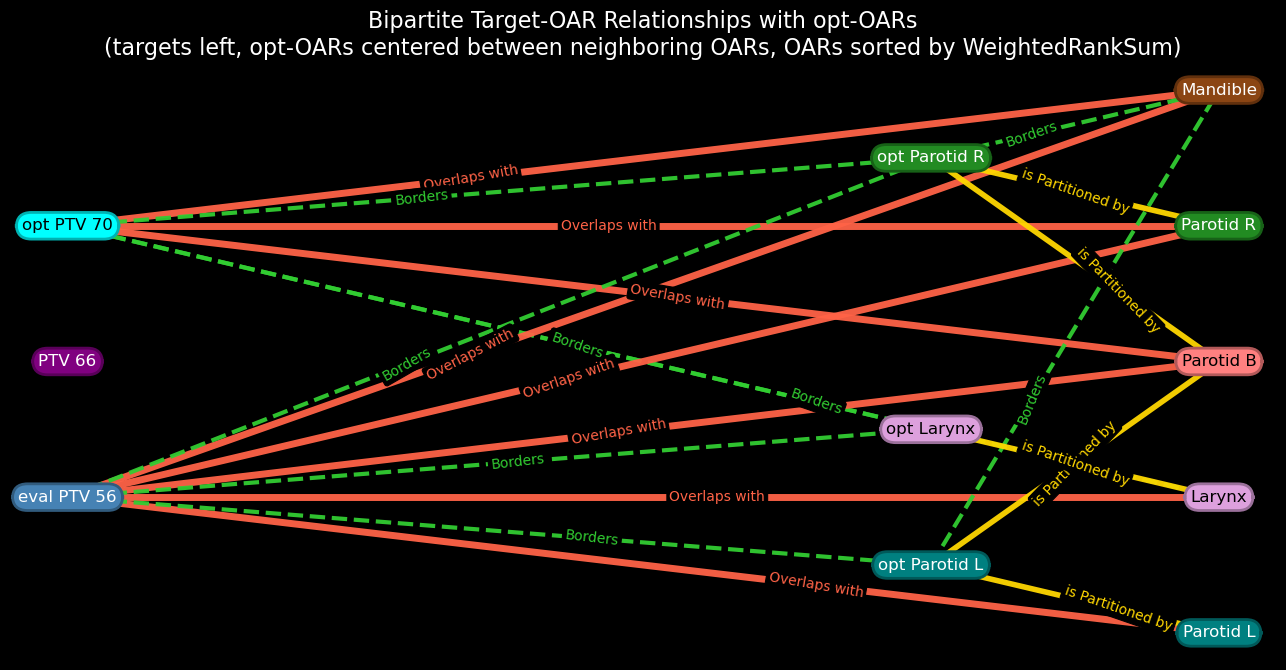

In [20]:
settings_path = base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json'
with open(settings_path, 'r', encoding='utf-8') as settings_file:
    diagram_settings = json.load(settings_file)

font_cfg = diagram_settings.get('diagram_options', {}).get('font', {})
font_dark_color = font_cfg.get('dark_color', '#000000')
font_light_color = font_cfg.get('light_color', '#FFFFFF')
figure_background = '#000000'

relationship_styles_cfg = diagram_settings.get('relationship_styles', {})
fallback_style = relationship_styles_cfg.get('UNKNOWN', {})

node_color_map = get_node_color_map(structure_set, default_color='#b7bec8')
summary_df = structure_set.summary()[['ROI', 'Name']].copy()
name_to_roi = summary_df.drop_duplicates('Name').set_index('Name')['ROI'].to_dict()

if 'opt_oar_matches' in globals() and not opt_oar_matches.empty:
    opt_nodes = opt_oar_matches.copy()
else:
    opt_nodes = pd.DataFrame(
        columns=['Structure ID', 'MatchedSelectedOARs', 'MatchedCount']
    )

bipartite_graph = nx.Graph()
for target_name in ordered_targets:
    roi = int(name_to_roi.get(target_name, -1))
    node_color = node_color_map.get(roi, '#4e79a7')
    bipartite_graph.add_node(
        target_name,
        side='target',
        node_color=node_color,
        node_border_color=darken_color(node_color),
        node_text_color=get_text_color(
            node_color,
            dark_color=font_dark_color,
            light_color=font_light_color,
        ),
    )

for oar_name in ordered_oars:
    roi = int(name_to_roi.get(oar_name, -1))
    node_color = node_color_map.get(roi, '#f28e2b')
    bipartite_graph.add_node(
        oar_name,
        side='oar',
        node_color=node_color,
        node_border_color=darken_color(node_color),
        node_text_color=get_text_color(
            node_color,
            dark_color=font_dark_color,
            light_color=font_light_color,
        ),
    )

for opt_name in opt_nodes.get('Structure ID', []):
    roi = int(name_to_roi.get(opt_name, -1))
    node_color = node_color_map.get(roi, '#2aa7a1')
    bipartite_graph.add_node(
        str(opt_name),
        side='opt',
        node_color=node_color,
        node_border_color=darken_color(node_color),
        node_text_color=get_text_color(
            node_color,
            dark_color=font_dark_color,
            light_color=font_light_color,
        ),
    )

for row in bipartite_edges.itertuples(index=False):
    bipartite_graph.add_edge(
        row.Target,
        row.OAR,
        category=row.Category,
        relation_type=row.RelationType,
        relationship_label=row.RelationshipLabel,
        weight=float(row.Weight),
    )

def relation_payload(source_name: str, target_name: str) -> dict | None:
    if source_name not in structure_set.relationship_matrix.index:
        return None
    if target_name not in structure_set.relationship_matrix.columns:
        return None
    rel = structure_set.relationship_matrix.at[source_name, target_name]
    if rel is None or pd.isna(rel):
        return None
    rel_type = rel.relationship_type
    category = str(rel_type.category)
    if category == 'Separate':
        return None
    return {
        'category': category,
        'relation_type': str(rel_type.relation_type).upper(),
        'relationship_label': str(rel_type.label),
        'weight': {'Shared': 1.0, 'Adjoining': 0.6}.get(category, 0.3),
    }

for opt_name in opt_nodes.get('Structure ID', []):
    opt_name = str(opt_name)
    for endpoint in ordered_targets + ordered_oars:
        edge_data = relation_payload(opt_name, endpoint)
        if edge_data is None:
            continue
        bipartite_graph.add_edge(endpoint, opt_name, **edge_data)

y_gap = 1.0
x_left = 0.0
x_right = 5.8
x_opt = x_right - 1.45
left_offset = ((len(ordered_targets) - 1) * y_gap) / 2
right_offset = ((len(ordered_oars) - 1) * y_gap) / 2

bipartite_pos = {}
for i, target_name in enumerate(ordered_targets):
    bipartite_pos[target_name] = (x_left, left_offset - (i * y_gap))
for i, oar_name in enumerate(ordered_oars):
    bipartite_pos[oar_name] = (x_right, right_offset - (i * y_gap))

oar_index_map = {name: idx for idx, name in enumerate(ordered_oars)}

def related_oars_for_opt(opt_name: str) -> list[str]:
    related = []
    for oar_name in ordered_oars:
        rel_data = relation_payload(opt_name, oar_name)
        if rel_data is not None:
            related.append(oar_name)
    return related

opt_anchor_map: dict[str, str] = {}
opt_neighbor_map: dict[str, str | None] = {}
placement_count: dict[tuple[str, str], int] = {}

for _, row in opt_nodes.iterrows():
    opt_name = str(row['Structure ID'])
    matched_oars = row.get('MatchedSelectedOARs', [])
    matched_oars = matched_oars if isinstance(matched_oars, list) else []

    anchor_oar = None
    for candidate in matched_oars:
        if candidate in ordered_oars:
            anchor_oar = candidate
            break
    if anchor_oar is None:
        related = related_oars_for_opt(opt_name)
        anchor_oar = related[0] if related else (ordered_oars[0] if ordered_oars else None)
    if anchor_oar is None:
        continue
    opt_anchor_map[opt_name] = anchor_oar

    anchor_idx = oar_index_map[anchor_oar]
    _, anchor_y = bipartite_pos[anchor_oar]
    related = [oar for oar in related_oars_for_opt(opt_name) if oar != anchor_oar]
    if related:
        related_mean_y = sum(bipartite_pos[oar][1] for oar in related) / len(related)
        preferred_up = related_mean_y >= anchor_y
    else:
        preferred_up = True

    if preferred_up and anchor_idx > 0:
        neighbor_oar = ordered_oars[anchor_idx - 1]
    elif (not preferred_up) and anchor_idx < len(ordered_oars) - 1:
        neighbor_oar = ordered_oars[anchor_idx + 1]
    elif anchor_idx > 0:
        neighbor_oar = ordered_oars[anchor_idx - 1]
    elif anchor_idx < len(ordered_oars) - 1:
        neighbor_oar = ordered_oars[anchor_idx + 1]
    else:
        neighbor_oar = None

    opt_neighbor_map[opt_name] = neighbor_oar

    if neighbor_oar is None:
        base_y = anchor_y
        direction = 1.0 if preferred_up else -1.0
        base_y += 0.32 * direction
    else:
        _, neighbor_y = bipartite_pos[neighbor_oar]
        base_y = (anchor_y + neighbor_y) / 2.0
        direction = 1.0 if base_y >= anchor_y else -1.0

    group_key = (anchor_oar, str(neighbor_oar))
    count_for_slot = placement_count.get(group_key, 0)
    placement_count[group_key] = count_for_slot + 1

    # Keep multiple opt nodes separated slightly while staying near the midpoint.
    jitter = direction * (0.07 * count_for_slot)
    bipartite_pos[opt_name] = (x_opt, base_y + jitter)

fig_height = max(
    6,
    0.85 * max(
        len(ordered_oars) + len(opt_nodes),
        len(ordered_targets),
    ),
 )
fig, ax = plt.subplots(figsize=(13, fig_height))
fig.patch.set_facecolor(figure_background)
ax.set_facecolor(figure_background)

edge_draw_rows = []
for source, target, edge_data in bipartite_graph.edges(data=True):
    sx, _ = bipartite_pos[source]
    tx, _ = bipartite_pos[target]
    if sx <= tx:
        edge_draw_rows.append((source, target, edge_data))
    else:
        edge_draw_rows.append((target, source, edge_data))

edges_by_source = {}
for source, target, edge_data in edge_draw_rows:
    edges_by_source.setdefault(source, []).append((source, target, edge_data))

label_fraction_map = {}
for source, grouped_edges in edges_by_source.items():
    grouped_edges = sorted(
        grouped_edges,
        key=lambda edge_row: bipartite_pos[edge_row[1]][1],
        reverse=True,
    )
    count = len(grouped_edges)
    if count == 1:
        fractions = [0.5]
    else:
        fractions = [0.35 + (0.30 * idx / (count - 1)) for idx in range(count)]
    for (edge_source, edge_target, _), fraction in zip(grouped_edges, fractions):
        label_fraction_map[(edge_source, edge_target)] = fraction

for source, target, edge_data in edge_draw_rows:
    relation_type = str(edge_data.get('relation_type', 'UNKNOWN')).upper()
    edge_style = normalize_edge_style(
        relationship_styles_cfg.get(relation_type, {}),
        fallback_style,
    )
    edge_color = edge_style['color']
    line_width = float(edge_style['width'])
    line_style = '--' if edge_style['dashes'] else '-'

    x0, y0 = bipartite_pos[source]
    x1, y1 = bipartite_pos[target]

    ax.plot(
        [x0, x1],
        [y0, y1],
        color=edge_color,
        linewidth=line_width,
        linestyle=line_style,
        solid_capstyle='round',
        alpha=0.95,
        zorder=3,
    )

    label_fraction = label_fraction_map.get((source, target), 0.5)
    mid_x = x0 + (label_fraction * (x1 - x0))
    mid_y = y0 + (label_fraction * (y1 - y0))
    angle_deg = math.degrees(math.atan2(y1 - y0, x1 - x0))
    if angle_deg > 90:
        angle_deg -= 180
    if angle_deg < -90:
        angle_deg += 180

    ax.text(
        mid_x,
        mid_y,
        str(edge_data.get('relationship_label', edge_data['category'])),
        color=edge_color,
        fontsize=10,
        ha='center',
        va='center',
        rotation=angle_deg,
        rotation_mode='anchor',
        bbox={
            'boxstyle': 'round,pad=0.18',
            'facecolor': figure_background,
            'edgecolor': figure_background,
            'linewidth': 0.8,
        },
        zorder=7,
    )

for node_name, node_data in bipartite_graph.nodes(data=True):
    if node_name not in bipartite_pos:
        continue
    x_coord, y_coord = bipartite_pos[node_name]
    ax.text(
        x_coord,
        y_coord,
        node_name,
        ha='center',
        va='center',
        fontsize=12,
        color=node_data['node_text_color'],
        bbox={
            'boxstyle': 'round,pad=0.35,rounding_size=0.9',
            'facecolor': node_data['node_color'],
            'edgecolor': node_data['node_border_color'],
            'linewidth': 2,
        },
        zorder=20,
    )

ax.set_title(
    'Bipartite Target-OAR Relationships with opt-OARs\n'
    '(targets left, opt-OARs centered between neighboring OARs, OARs sorted by WeightedRankSum)',
    color=font_light_color,
    fontsize=16,
 )
ax.axis('off')
plt.tight_layout()
